# ENTRENAMIENTO DE MODELOS
---

### Clasificación de galaxias según su morfología

#### Integrantes

- `Crespo Neri, Diego Ubaldo` (`ubaldo.crespo@iteso.mx`)
- `Garibay Zepeda, Julio Andrés` (`julio.garibay@iteso.mx`)
- `Vázquez Sandoval, Isaac Ernesto` (`isaac.vazquez@iteso.mx`)

---
---

### Bibliotecas

In [1]:
# Básicas
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import pyplot as plt
from sklearn.metrics import (accuracy_score, auc, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted

In [2]:
# NN
import keras_tuner as kt
import tensorflow as tf
from keras.callbacks import EarlyStopping
from keras.layers import (BatchNormalization, Conv2D, Dense, Dropout, Flatten,
                          Input, MaxPooling2D, ReLU)
from keras.models import Sequential
from keras.optimizers import Adam
from keras.regularizers import l2

2025-11-21 19:27:52.568482: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-21 19:27:52.613674: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-21 19:27:53.873237: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
# SV
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [4]:
# LR
from sklearn.linear_model import LogisticRegression

In [5]:
# Swag
style = "/home/toutl/code/.machine.mplstyle"
if os.path.exists(style):
    plt.style.use(style)

In [6]:
# Stablish seeds
SEED = 35

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Para keras
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

---
---

### Data:

##### 1. Lectura de los datos

In [7]:
# Paths de las carpetas donde se encuentran los datos
data_folder = Path("../../data/classification/")
processed_folder = data_folder / "processed"

In [8]:
# Leemos la metadata (etiquetas e ids)
metadata_df = pd.read_csv(processed_folder / "sample_64x64_10570.csv").astype(str)
display(metadata_df.head())

,image_id,class
0,110581,0
1,53890,0
2,268229,0
3,69751,0
4,294591,0


In [9]:
# Cargamos las imágenes procesadas
processed_images = np.load(processed_folder / "sample_64x64_10570.npz")
files = processed_images.files
print(files[:10])
print(len(files))

['110581', '53890', '268229', '69751', '294591', '287069', '58579', '49874', '17922', '7030']
10570


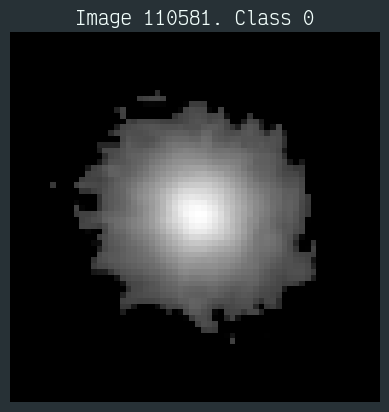

In [10]:
# Ejemplo de uso de una imágen
img_name = files[0]
idx = metadata_df.index[metadata_df["image_id"] == img_name][0]
img_class = metadata_df.at[idx, "class"]

plt.imshow(processed_images[img_name], cmap="gray")
plt.title(f"Image {img_name}. Class {img_class}")
plt.axis("off")
plt.show()

In [11]:
# Obtenemos un arreglo con todas las imágenes
images_ids = metadata_df["image_id"].to_list()

images_array = np.empty((len(metadata_df), 64, 64), dtype=np.float32)

for i, img_name in enumerate(images_ids):
    image = processed_images[img_name]

    # Asegurarse que las imágenes estén normalizadas
    if image.max() > 1 or image.min() < 0:
        raise ValueError(f"Image {img_name} not normalized.")

    images_array[i] = image

In [12]:
# Revisando la cantidad de etiquetas respecto a la cantidad de imágenes, y congruencia de tamaños
print(images_array.shape, metadata_df["class"].shape)

(10570, 64, 64) (10570,)


---

##### 2. Separación de datos en entrenamiento y prueba

In [13]:
# Objeto que encapsule los datos
class Data:
    def __init__(self, X, y, random_state=SEED):
        # Splits
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=random_state, stratify=y
        )
        x_train, x_valid, y_train, y_valid = train_test_split(
            x_train, y_train, test_size=0.2, random_state=random_state, stratify=y_train
        )

        # Agregar canal
        self.X_train = x_train[..., None]
        self.X_valid = x_valid[..., None]
        self.X_test = x_test[..., None]

        self.y_train = np.asarray(y_train)
        self.y_valid = np.asarray(y_valid)
        self.y_test = np.asarray(y_test)

        # Validar shapes
        assert self.X_train.shape[1:] == (64, 64, 1), "Unexpected image shape"
        assert len(self.X_train) == len(self.y_train), "Train feature/label mismatch"
        assert len(self.X_valid) == len(self.y_valid), "Valid feature/label mismatch"
        assert len(self.X_test) == len(self.y_test), "Test feature/label mismatch"

        # Validar labels
        unique_labels = np.unique(y)
        assert set(unique_labels) <= {0, 1}, f"Unexpected labels found: {unique_labels}"

    # Crear versiones planas
    def _flatten(self, X):
        return X.reshape(len(X), -1)

    @property
    def X_train_flat(self):
        return self._flatten(self.X_train)

    @property
    def X_valid_flat(self):
        return self._flatten(self.X_valid)

    @property
    def X_test_flat(self):
        return self._flatten(self.X_test)

In [14]:
# Se genera el objeto para los datos
data = Data(
    X=images_array.astype("float32"),
    y=metadata_df["class"].astype("int8"),
)

In [15]:
# Checar
display(data.X_test_flat.shape)

(2114, 4096)

---
---

### Modelos:

#### Introducción

El primer objetivo a probar será comparar 4 modelos sencillos para una clasificación de imágenes de galaxias como se ha estado trabajando.

La clasificaición será binaria siendo...
- `0`: S, galaxias con forma espiral.
- `1`: E, morfología elíptica.

Recordando que como outliers de la clasificación se consideran otros Artefactos u Objetos distintos a galaxias.

Los modelos a utilizar serán 4:

- **CNN** (Red Neuronal Convolucional): 
- **MLP** (Perceptrón MultiCapa): 
- **SVC** (Clasificador de Soporte Vectorial): 
- **LR** (Regresión Logística): 

Las métricas consideradas para evaluar dichos modelos, deberán ser congruentes para el problema, una clasificación binaria.

Por lo tanto se utilizarán:

- Accuracy:
  - Indica la proporción de aciertos.
  - Podría cargar un ligero sesgo debido al que las clases tinene un balance de `60:40`, por esto mismo se complementa con otras métricas.

- Precision, Recall y F1-score:
  - Muestran el comportamiento del modelo con cada clase.
  - El F1 combina precisión y recall en un solo número.

- ROC–AUC:
  - Mide la capacidad del modelo para separar las dos clases.

La estructura del programa es la siguiente:
1. Se cargan los datos y separan en conjuntos de entrenamiento, validación y prueba.
2. Se entrenará una instancia sencilla de cada modelo.
    - Luego se compararán en bruto.
3. Con técnicas de ajuste de hiperparámetros se buscarán mejores versiones de cada modelo.
    - Y una comparación se realizará con los que obtengan las mejores métricas de cada uno.
4. Finalmente, se entrenará el mejor modelo que se haya obtenido con los datos sobrantes del muestreo y con la totalidad de los obtenidos.

---

#### Básicos
---

##### 1. CNN

In [73]:
def visualize_training(hist):
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history["val_accuracy"])
    plt.title("accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epochs")
    plt.ylim((0, 1))
    plt.xlim((0, 20))
    plt.legend(["training", "validation"], loc="lower right")
    plt.show()

    # training vs validation loss
    plt.plot(hist.history["loss"])
    plt.plot(hist.history["val_loss"])
    plt.title("loss")
    plt.ylabel("loss")
    plt.xlabel("epochs")
    plt.ylim((0, 1))
    plt.xlim((0, 20))
    plt.legend(["training", "validation"], loc="upper right")
    plt.show()

In [74]:
def build_binary_cnn(data):
    model = Sequential()

    model.add(Input(shape=data.X_train.shape[1:]))

    model.add(Conv2D(filters=32, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=32, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=64, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=128, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Dropout(0.2))
    model.add(Flatten())

    model.add(Dense(128))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(0.3))

    model.add(Dense(1, activation="sigmoid"))

    optimizer = Adam(learning_rate=3e-4)
    model.compile(
        loss="binary_crossentropy",
        optimizer=optimizer,  # type: ignore
        metrics=["accuracy", "AUC"],
    )

    return model

In [75]:
# Callbacks para el fit del modelo, funcionan para encontrar el mejor epoch
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [76]:
cnn_model = build_binary_cnn(data)
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 365,857 (1.40 MB)

 Trainable params: 365,089 (1.39 MB)

 Non-trainable params: 768 (3.00 KB)

In [77]:
hist_cnn = cnn_model.fit(
    data.X_train,
    data.y_train,
    batch_size=32,
    epochs=20,
    validation_data=(data.X_valid, data.y_valid),
    callbacks=[early_stop],
)

Epoch 1/20


2025-11-21 19:04:14.810960: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


211/212 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - AUC: 0.7158 - accuracy: 0.6762 - loss: 0.6386

2025-11-21 19:04:35.277613: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


212/212 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - AUC: 0.7356 - accuracy: 0.6904 - loss: 0.6231 - val_AUC: 0.4096 - val_accuracy: 0.5881 - val_loss: 1.5655
Epoch 2/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - AUC: 0.7876 - accuracy: 0.7266 - loss: 0.5575 - val_AUC: 0.7751 - val_accuracy: 0.5881 - val_loss: 1.5198
Epoch 3/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - AUC: 0.8038 - accuracy: 0.7398 - loss: 0.5386 - val_AUC: 0.8212 - val_accuracy: 0.7051 - val_loss: 0.5985
Epoch 4/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - AUC: 0.8198 - accuracy: 0.7525 - loss: 0.5170 - val_AUC: 0.8480 - val_accuracy: 0.7358 - val_loss: 0.5435
Epoch 5/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - AUC: 0.8334 - accuracy: 0.7602 - loss: 0.4971 - val_AUC: 0.8574 - val_accuracy: 0.7902 - val_loss: 0.4795
Epoch 6/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - AUC: 0.8499 - accuracy: 0.7759 - loss: 0.4747 - val_AUC: 0.8597 - val_accuracy: 0.7547 - val_loss: 0.5115
Epoch 7/20
212/212 ━━━━━━━━━━━━━━━━━━━

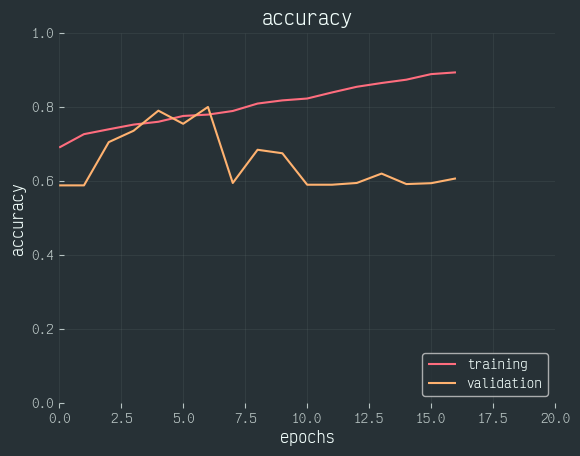

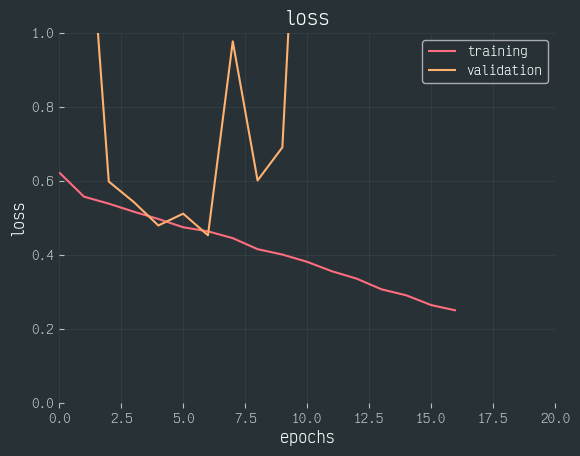

2025-11-21 19:09:55.112488: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Accuracy CNN: 74.88%


In [78]:
visualize_training(hist_cnn)

score_cnn = cnn_model.evaluate(data.X_test, data.y_test, verbose="0")
print(f"Accuracy CNN: {score_cnn[1] * 100:.2f}%")

---

##### 2. MLP

In [79]:
def build_binary_mlp(data: Data):
    model = Sequential()

    model.add(Input(shape=data.X_train.shape[1:]))
    model.add(Flatten())

    model.add(Dense(256, activation="relu", kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.3))

    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.3))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(3e-4),  # type: ignore
        metrics=["accuracy", "AUC"],
    )

    return model

In [80]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [81]:
mlp_model = build_binary_mlp(data)
mlp_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,081,857 (4.13 MB)

 Trainable params: 1,081,857 (4.13 MB)

 Non-trainable params: 0 (0.00 B)

In [82]:
hist_mlp = mlp_model.fit(
    data.X_train,
    data.y_train,
    batch_size=32,
    epochs=40,
    validation_data=(data.X_valid, data.y_valid),
    callbacks=[early_stop],
)

Epoch 1/40
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - AUC: 0.5312 - accuracy: 0.5735 - loss: 0.7238 - val_AUC: 0.5961 - val_accuracy: 0.5875 - val_loss: 0.6952
Epoch 2/40
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.5893 - accuracy: 0.5874 - loss: 0.6982 - val_AUC: 0.6408 - val_accuracy: 0.5875 - val_loss: 0.6795
Epoch 3/40
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.6066 - accuracy: 0.5930 - loss: 0.6878 - val_AUC: 0.6430 - val_accuracy: 0.5875 - val_loss: 0.6781
Epoch 4/40
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - AUC: 0.6256 - accuracy: 0.6056 - loss: 0.6762 - val_AUC: 0.6858 - val_accuracy: 0.5957 - val_loss: 0.6611
Epoch 5/40
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.6432 - accuracy: 0.6169 - loss: 0.6700 - val_AUC: 0.7120 - val_accuracy: 0.5940 - val_loss: 0.6557
Epoch 6/40
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.6594 - accuracy: 0.6345 - loss: 0.6593 - val_AUC: 0.7194 - val_accuracy: 0.6566 - val_loss: 0.6471
Epoch 7/40
212/212 ━━━━━━━━━━━━━━━━

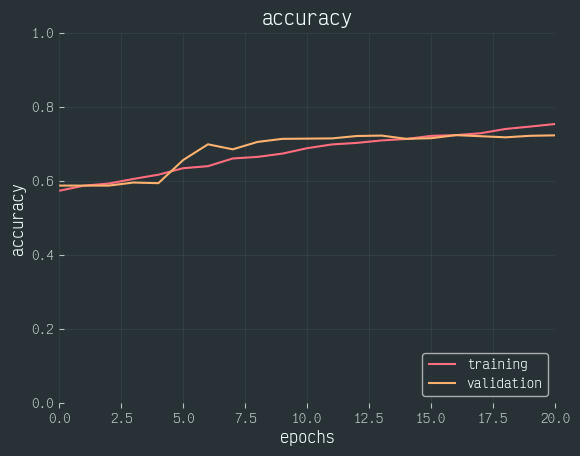

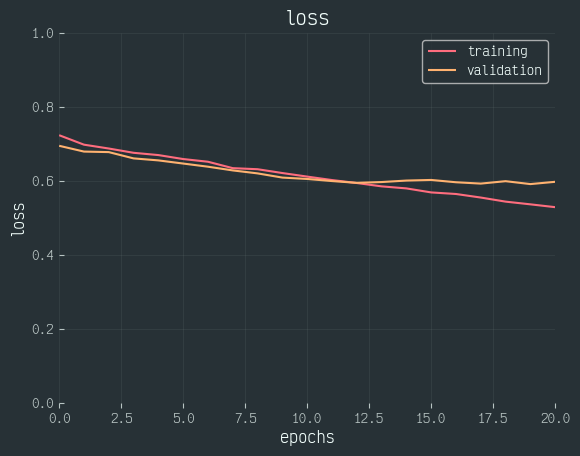

Accuracy MLP: 70.06%


2025-11-21 19:11:00.385637: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [83]:
visualize_training(hist_mlp)

score_mlp = mlp_model.evaluate(data.X_test, data.y_test, verbose="0")
print(f"Accuracy MLP: {score_mlp[1] * 100:.2f}%")

---

##### 3. Support Vector Classifier

In [84]:
svc_model = SVC(kernel="rbf", C=5, gamma=0.001, class_weight="balanced")

svc_model.fit(data.X_train_flat, data.y_train)

,C,5
,kernel,'rbf'
,degree,3
,gamma,0.001
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [85]:
y_pred = svc_model.predict(data.X_valid_flat)
print(classification_report(data.y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.68      0.74       995
           1       0.63      0.78      0.70       697

    accuracy                           0.72      1692
   macro avg       0.73      0.73      0.72      1692
weighted avg       0.74      0.72      0.73      1692



---

##### 4. Logistic Regression

In [86]:
logreg_model = LogisticRegression(max_iter=200, solver="liblinear")
logreg_model.fit(data.X_train_flat, data.y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,200
,multi_class,'deprecated'


In [87]:
y_pred = logreg_model.predict(data.X_valid_flat)
print(classification_report(data.y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73       995
           1       0.61      0.56      0.58       697

    accuracy                           0.67      1692
   macro avg       0.66      0.65      0.66      1692
weighted avg       0.67      0.67      0.67      1692



---

##### - Métricas

In [82]:
def get_scores(model, data, split="test", threshold=0.5):
    X = getattr(data, f"X_{split}")
    X_flat = getattr(data, f"X_{split}_flat")

    if "keras" in str(type(model)).lower():
        y_score = model.predict(X, verbose=0).reshape(-1)
        y_pred = (y_score >= threshold).astype(int)
        return y_score, y_pred

    if hasattr(model, "decision_function"):
        y_score = model.decision_function(X_flat)
        y_pred = (y_score >= threshold).astype(int)
        return y_score, y_pred

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_flat)[:, 1]
        y_pred = (y_score >= threshold).astype(int)
        return y_score, y_pred

    y_pred = model.predict(X_flat)
    return None, y_pred

In [83]:
def visualize_metrics(models, data, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0, 1, 200)

    plt.figure(figsize=(16, 5))

    # 1. ROC Curve
    plt.subplot(1, 3, 1)
    for name, model in models.items():

        y_score, _ = get_scores(model, data)

        if y_score is None:
            continue

        fpr, tpr, _ = roc_curve(data.y_test, y_score)
        model_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={model_auc:.3f})")

    plt.plot([0, 1], [0, 1], "w--")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    # 2. Precision–Recall Curve
    plt.subplot(1, 3, 2)
    for name, model in models.items():

        y_score, _ = get_scores(model, data)

        if y_score is None:
            continue

        precision, recall, _ = precision_recall_curve(data.y_test, y_score)
        plt.plot(recall, precision, label=name)

    plt.title("Precision–Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    # 3. F1 vs Threshold
    plt.subplot(1, 3, 3)
    for name, model in models.items():

        y_score, _ = get_scores(model, data)

        if y_score is None:
            continue

        f1_scores = []
        for t in thresholds:
            y_pred = (y_score >= t).astype(int)
            f1_scores.append(f1_score(data.y_test, y_pred, zero_division=0))

        plt.plot(thresholds, f1_scores, label=name)

    plt.title("F1 vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [88]:
def evaluate_models2(models: dict, data: Data, threshold=0.5):
    results = []

    for name, model in models.items():

        # Predicción
        start = time.time()

        if hasattr(model, "predict") and "keras" in str(type(model)).lower():
            y_prob = model.predict(data.X_test, verbose=0).reshape(-1)
            y_pred = (y_prob >= threshold).astype(int)

        else:
            check_is_fitted(model)

            if hasattr(model, "decision_function"):
                y_prob = model.decision_function(data.X_test_flat)
                y_pred = model.predict(data.X_test_flat)

            elif hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(data.X_test_flat)[:, 1]
                y_pred = model.predict(data.X_test_flat)

            else:
                y_prob = None
                y_pred = model.predict(data.X_test_flat)

        runtime = time.time() - start

        # Métricas
        acc = accuracy_score(data.y_test, y_pred)
        prec = precision_score(data.y_test, y_pred, zero_division=0)
        rec = recall_score(data.y_test, y_pred, zero_division=0)
        f1 = f1_score(data.y_test, y_pred, zero_division=0)

        # ROC–AUC si hay probabilidades
        if y_prob is not None:
            try:
                auc = roc_auc_score(data.y_test, y_prob)
            except ValueError:
                auc = np.nan
        else:
            auc = np.nan

        # Complejidad aprox (número de parámetros)
        if hasattr(model, "count_params"):
            params = model.count_params()
        elif hasattr(model, "coef_"):
            params = model.coef_.size + model.intercept_.size
        # elif "svc" in name:
        #     params = model.support_vectors_.shape[0]
        else:
            params = np.nan

        results.append(
            {
                "Modelo": name,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1": f1,
                "ROC-AUC": auc,
                "Parámetros": params,
                "Tiempo_inferencia_s": runtime,
            }
        )

    return pd.DataFrame(results)

In [85]:
def plot_confusion_matrices(models, data, threshold=0.5):
    n = len(models)
    plt.figure(figsize=(4 * n, 4))

    for i, (name, model) in enumerate(models.items(), 1):
        _, y_pred = get_scores(model, data, threshold=threshold)
        cm = confusion_matrix(data.y_test, y_pred)

        plt.subplot(1, n, i)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")

    plt.tight_layout()
    plt.show()

In [98]:
basic_models = {
    "cnn": cnn_model,
    "mlp": mlp_model,
    "svc": svc_model,
    "logreg": logreg_model,
}

2025-11-21 19:16:39.667269: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-11-21 19:17:05.549291: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

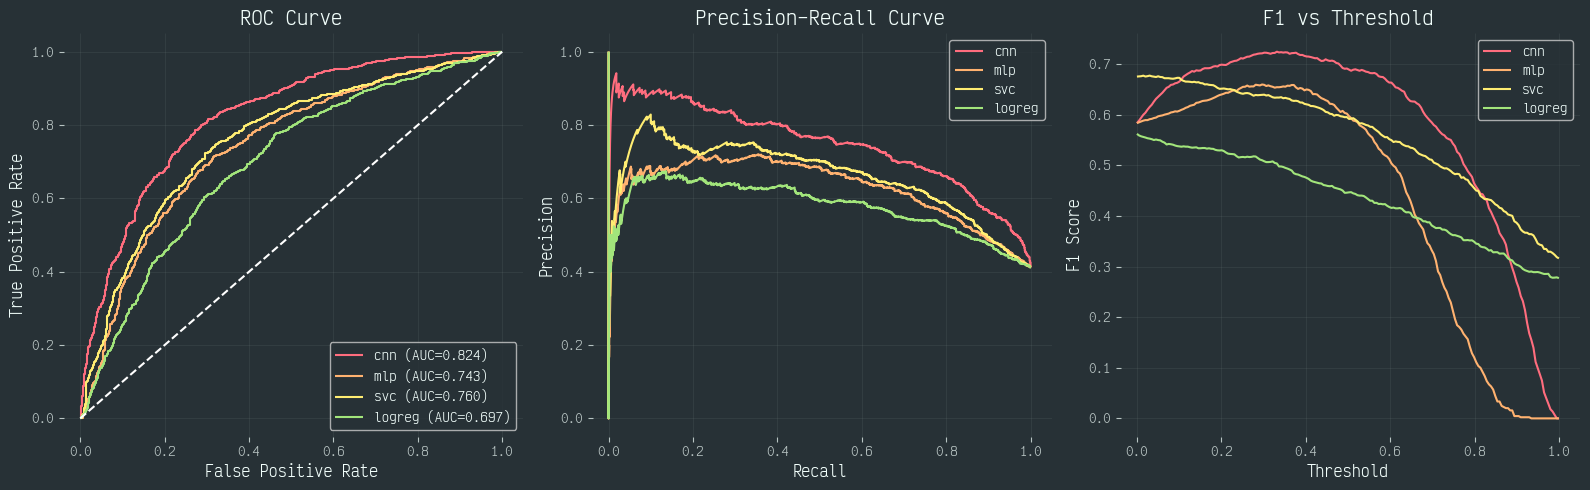

2025-11-21 19:17:58.549204: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,Parámetros,Tiempo_inferencia_s
0,cnn,0.75,0.67,0.76,0.71,0.82,365857,1.22
1,mlp,0.70,0.63,0.68,0.65,0.74,1081857,0.20
2,svc,0.70,0.61,0.76,0.68,0.76,5129,44.54
3,logreg,0.66,0.59,0.54,0.56,0.70,4097,0.04


In [99]:
visualize_metrics(models=basic_models, data=data)

results = evaluate_models2(models=basic_models, data=data, threshold=0.4)
results.round(2)

2025-11-21 19:19:44.571744: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


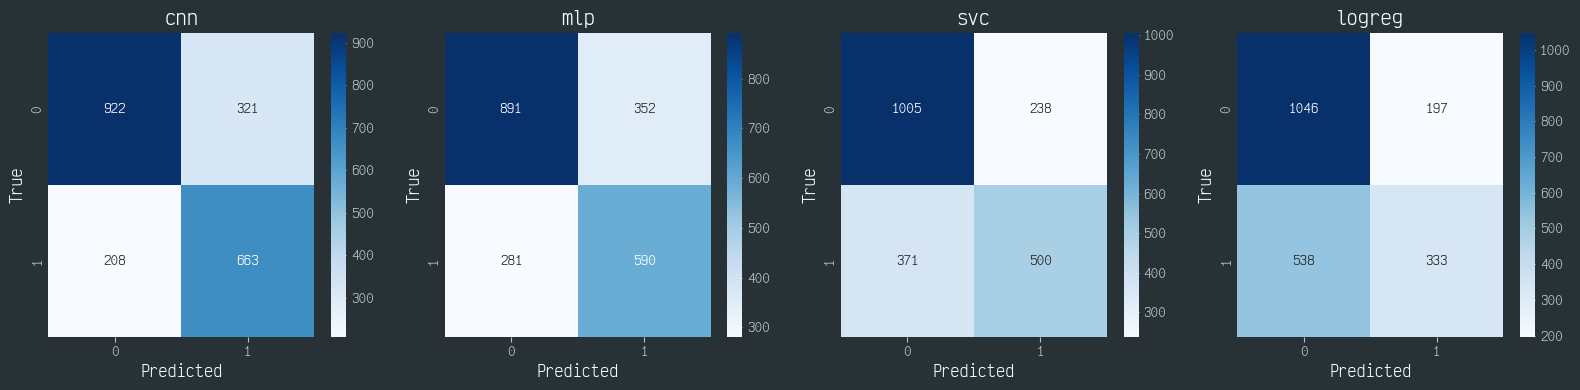

In [103]:
plot_confusion_matrices(basic_models, data, threshold=0.4)

**Algunas conclusiones:**

- 

-

#### Con ajuste de hiper-parámetros
---

In [25]:
def evaluate_models(models, data, threshold=0.5):
    rows = []

    for name, model in models.items():
        y_score, y_pred = get_scores(model, data, threshold=threshold)

        acc  = accuracy_score(data.y_test, y_pred)
        prec = precision_score(data.y_test, y_pred, zero_division=0)
        rec  = recall_score(data.y_test, y_pred, zero_division=0)
        f1   = f1_score(data.y_test, y_pred, zero_division=0)

        # AUC solo cuando hay scores continuos
        if y_score is not None:
            try:
                auc_value = roc_auc_score(data.y_test, y_score)
            except ValueError:
                auc_value = np.nan
        else:
            auc_value = np.nan

        rows.append({
            "Modelo": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "AUC": auc_value
        })

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)

##### 1. CNN

In [ ]:
def build_cnn_model(hp):
    model = Sequential()

    # HP
    f = hp.Choice("filters", [64, 128])
    d = hp.Choice("dropout", [0.3, 0.4])
    lr = hp.Choice("lr", [1e-4, 1e-3])

    model.add(Input(shape=data.X_train.shape[1:]))

    model.add(Conv2D(filters=64, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=64, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=f, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=128, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Dropout(d))
    model.add(Flatten())

    model.add(Dense(128))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(0.3))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=lr),  # type: ignore
        metrics=["accuracy", "AUC"],
    )

    return model



In [22]:
cnn_tuner = kt.RandomSearch(
    build_cnn_model,
    objective="val_accuracy",
    max_trials=10,
    directory="cnn_tuning",
    project_name="cnn_binary",
)

cnn_tuner.search(
    data.X_train, data.y_train, validation_data=(data.X_valid, data.y_valid), epochs=10
)

Trial 8 Complete [00h 07m 43s]
val_accuracy: 0.7748227119445801

Best val_accuracy So Far: 0.8055555820465088
Total elapsed time: 00h 59m 32s


In [23]:
best_cnn = cnn_tuner.get_best_models(num_models=1)[0]
best_cnn.summary()

/home/toutl/icd/lmd/project/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 523,457 (2.00 MB)

 Trainable params: 522,433 (1.99 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [40]:
best_hp = cnn_tuner.get_best_hyperparameters(1)[0]
best_hp.values

{'filters': 128, 'dropout': 0.3, 'lr': 0.0001}

In [27]:
evaluate_models({"best_cnn": best_cnn}, data).round(3)

2025-11-21 20:31:18.109938: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Modelo,Accuracy,Precision,Recall,F1,AUC
0,best_cnn,0.758,0.7,0.724,0.712,0.83


---

##### 2. MLP

In [ ]:
def build_mlp_model(hp):
    model = Sequential()

    # HP
    u1 = hp.Choice("units1", [128, 256])
    u2 = hp.Choice("units2", [128, 256])
    d = hp.Choice("dropout", [0.3, 0.4])
    lr = hp.Choice("lr", [1e-4, 1e-3])

    model.add(Input(shape=data.X_train.shape[1:]))
    model.add(Flatten())

    model.add(Dense(units=u1, activation="relu"))
    model.add(Dropout(0.3))

    model.add(Dense(units=u2, activation="relu"))
    model.add(Dropout(d))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=lr),  # type: ignore
        metrics=["accuracy", "AUC"],
    )

    return model

In [36]:
mlp_tuner = kt.RandomSearch(
    build_mlp_model,
    objective="val_accuracy",
    max_trials=10,
    directory="mlp_tuning",
    project_name="cnn_binary",
)

mlp_tuner.search(
    data.X_train, data.y_train, validation_data=(data.X_valid, data.y_valid), epochs=15
)

Trial 10 Complete [00h 00m 32s]
val_accuracy: 0.6968085169792175

Best val_accuracy So Far: 0.7346335649490356
Total elapsed time: 00h 04m 14s


In [37]:
best_mlp = mlp_tuner.get_best_models(num_models=1)[0]
best_mlp.summary()

/home/toutl/icd/lmd/project/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,697 (2.13 MB)

 Trainable params: 557,697 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
best_hp = mlp_tuner.get_best_hyperparameters(1)[0]
best_hp.values

{'units1': 128, 'units2': 256, 'dropout': 0.3, 'lr': 0.0001}

In [39]:
evaluate_models({"best_mlp": best_mlp}, data).round(2)

2025-11-21 20:40:43.954103: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Modelo,Accuracy,Precision,Recall,F1,AUC
0,best_mlp,0.7,0.65,0.61,0.63,0.74


---

##### 3. Support Vector Classifier

In [61]:
import warnings
import os

warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")
warnings.filterwarnings("ignore", module=r".*multiprocessing.queues")

warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning:pkg_resources"

In [46]:
svc_pipe = Pipeline([
    ("pca", PCA(whiten=True, random_state=35)),
    ("svc", SVC(kernel="rbf", class_weight="balanced"))
])

param_grid = {
    "pca__n_components": [50, 100, 150, 200],
    "svc__C": [5],  # previas iteraciones nos indicaron este valor como el único útil
    "svc__gamma": [0.0011, 0.0012, 0.00013],
}

svc_grid = GridSearchCV(
    svc_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    n_jobs=-1,
    cv=5,
    verbose=2
)

svc_grid.fit(data.X_train_flat, data.y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/home/toutl/.local/share/uv/python/cpython-3.11.9-linux-x86_64-gnu/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/toutl/.local/share/uv/python/cpython-3.11.9-linux-x86_64-gnu/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/toutl/.local/share/uv/python/cpython-3.11.9-linux-x86_64-gnu/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resource

[CV] END .pca__n_components=50, svc__C=5, svc__gamma=0.00013; total time=   5.9s
[CV] END ..pca__n_components=50, svc__C=5, svc__gamma=0.0012; total time=   5.8s
[CV] END ..pca__n_components=50, svc__C=5, svc__gamma=0.0011; total time=   6.8s
[CV] END ..pca__n_components=50, svc__C=5, svc__gamma=0.0011; total time=   7.1s
[CV] END .pca__n_components=50, svc__C=5, svc__gamma=0.00013; total time=   6.8s
[CV] END ..pca__n_components=50, svc__C=5, svc__gamma=0.0011; total time=   7.6s
[CV] END ..pca__n_components=50, svc__C=5, svc__gamma=0.0012; total time=   8.1s
[CV] END ..pca__n_components=50, svc__C=5, svc__gamma=0.0012; total time=   8.3s
[CV] END ..pca__n_components=50, svc__C=5, svc__gamma=0.0012; total time=   7.7s
[CV] END ..pca__n_components=50, svc__C=5, svc__gamma=0.0011; total time=   8.2s
[CV] END ..pca__n_components=50, svc__C=5, svc__gamma=0.0012; total time=   8.3s
[CV] END ..pca__n_components=50, svc__C=5, svc__gamma=0.0011; total time=   9.0s
[CV] END .pca__n_components=

,estimator,Pipeline(step...'balanced'))])
,param_grid,"{'pca__n_components': [50, 100, ...], 'svc__C': [5], 'svc__gamma': [0.0011, 0.0012, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,100


In [47]:
print(f"Best Params: {svc_grid.best_params_}")
print(f"Best Cross-Val AUC: {svc_grid.best_score_:.4f}")

Best Params: {'pca__n_components': 100, 'svc__C': 5, 'svc__gamma': 0.0012}
Best Cross-Val AUC: 0.7711


In [50]:
y_pred = svc_grid.predict(data.X_test_flat)
y_proba = svc_grid.decision_function(data.X_test_flat)

print(classification_report(data.y_test, y_pred))

print(f"\nTest Set ROC AUC: {roc_auc_score(data.y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.80      0.65      0.72      1243
           1       0.61      0.77      0.68       871

    accuracy                           0.70      2114
   macro avg       0.71      0.71      0.70      2114
weighted avg       0.72      0.70      0.70      2114


Test Set ROC AUC: 0.7687


In [51]:
best_svc = svc_grid.best_estimator_
evaluate_models({"best_svc": best_svc}, data).round(2)

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,best_svc,0.72,0.69,0.56,0.62,0.77


---

##### 4. Logistic Regression

In [68]:
warnings.filterwarnings('ignore')

In [76]:
logreg_pipe = Pipeline(
    [
        ("pca", PCA(random_state=35)),
        ("logreg", LogisticRegression(solver="liblinear", max_iter=1000)),
    ]
)

param_grid = {
    "pca__n_components": [0.95, 0.9, 0.85],
    "logreg__C": [0.005, 0.01, 0.015],
    "logreg__penalty": ["l1"],
}

logreg_grid = GridSearchCV(
    logreg_pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1, verbose=2
)

logreg_grid.fit(data.X_train_flat, data.y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


/home/toutl/.local/share/uv/python/cpython-3.11.9-linux-x86_64-gnu/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/toutl/.local/share/uv/python/cpython-3.11.9-linux-x86_64-gnu/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/toutl/.local/share/uv/python/cpython-3.11.9-linux-x86_64-gnu/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resource

[CV] END logreg__C=0.005, logreg__penalty=l1, pca__n_components=0.9; total time= 3.5min
[CV] END logreg__C=0.005, logreg__penalty=l1, pca__n_components=0.9; total time= 3.6min
[CV] END logreg__C=0.005, logreg__penalty=l1, pca__n_components=0.85; total time= 3.6min
[CV] END logreg__C=0.005, logreg__penalty=l1, pca__n_components=0.9; total time= 3.6min
[CV] END logreg__C=0.005, logreg__penalty=l1, pca__n_components=0.85; total time= 3.6min
[CV] END logreg__C=0.005, logreg__penalty=l1, pca__n_components=0.95; total time= 3.6min
[CV] END logreg__C=0.005, logreg__penalty=l1, pca__n_components=0.9; total time= 3.6min
[CV] END logreg__C=0.005, logreg__penalty=l1, pca__n_components=0.95; total time= 3.6min
[CV] END logreg__C=0.005, logreg__penalty=l1, pca__n_components=0.95; total time= 3.6min
[CV] END logreg__C=0.005, logreg__penalty=l1, pca__n_components=0.9; total time= 3.6min
[CV] END logreg__C=0.005, logreg__penalty=l1, pca__n_components=0.95; total time= 3.6min
[CV] END logreg__C=0.005, 

,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'logreg__C': [0.005, 0.01, ...], 'logreg__penalty': ['l1'], 'pca__n_components': [0.95, 0.9, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_components,0.95


In [77]:
print(f"Best Params: {logreg_grid.best_params_}\n")

y_pred = logreg_grid.predict(data.X_test_flat)
print(classification_report(data.y_test, y_pred))

Best Params: {'logreg__C': 0.015, 'logreg__penalty': 'l1', 'pca__n_components': 0.95}

              precision    recall  f1-score   support

           0       0.70      0.79      0.74      1243
           1       0.63      0.51      0.56       871

    accuracy                           0.68      2114
   macro avg       0.66      0.65      0.65      2114
weighted avg       0.67      0.68      0.67      2114



In [78]:
best_logreg = logreg_grid.best_estimator_
evaluate_models({"best_logreg": best_logreg}, data).round(2)

,Modelo,Accuracy,Precision,Recall,F1,AUC
0,best_logreg,0.61,0.65,0.14,0.23,0.72


#### General evaluación

In [79]:
best_models = {
    "best_cnn": best_cnn,
    "best_mlp": best_mlp,
    "best_svc": best_svc,
    "best_logreg": best_logreg,
}

In [89]:
evaluate_models(best_models, data).round(3)

2025-11-21 21:28:27.994077: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,Parámetros,Tiempo_inferencia_s
0,best_cnn,0.758,0.700,0.724,0.712,0.830,523457.0,2.322
1,best_mlp,0.703,0.648,0.612,0.630,0.744,557697.0,0.232
2,best_svc,0.701,0.609,0.769,0.680,0.769,NaN,1.084
3,best_logreg,0.675,0.633,0.506,0.562,0.718,NaN,0.046


2025-11-21 21:31:04.418368: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-11-21 21:31:09.898925: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

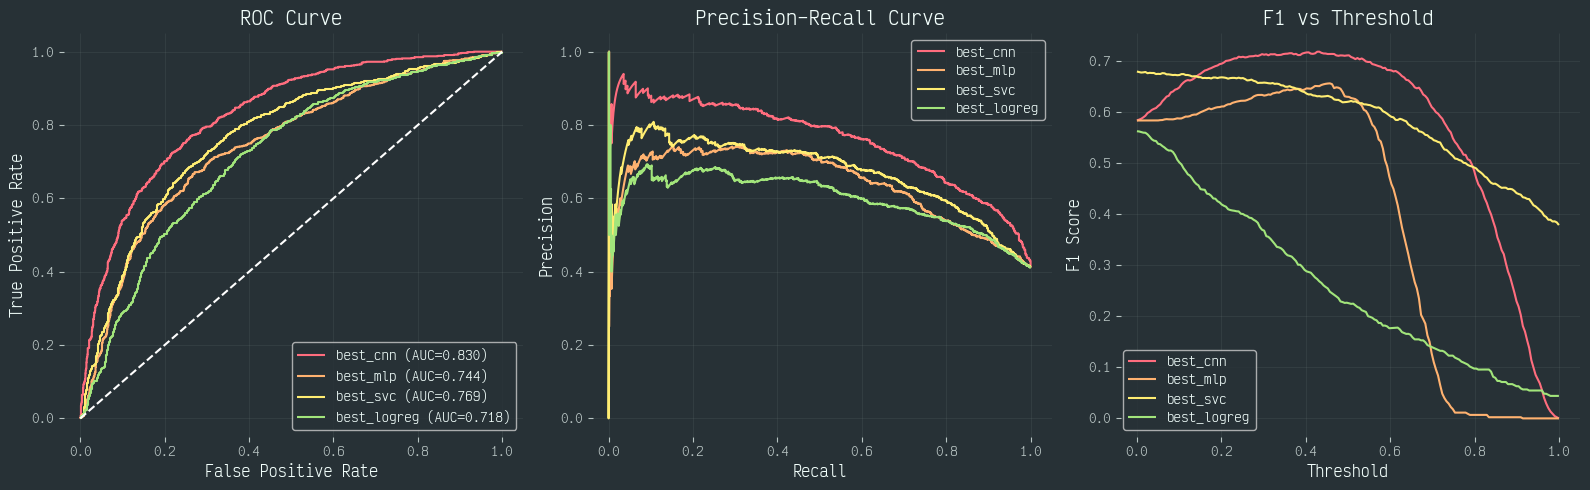

In [90]:
visualize_metrics(models=best_models, data=data)

#

Las conclusiones de los modelos utilizados fueron: 

- **CNN** (Red Neuronal Convolucional): 
    - Es la favorita. El estado del arte para imágenes.
    - Representa un sistema visual, capaz de detectar bordes, texturas y formas.
    - Aprende patrones complejos a costa de una gran cantidad de imágenes (lo cual cumplimos).
    - Tuvo la mejor capacidad para distinguir las clases de las imagenes basandonos en las graficas de las metricas.
    - la cantidad de parametros fueron alrededor de 0.5m
    - y su tiempo fue 10 veces mas a comparacion de mlp siendo la mas tardada seguida de svc
     
- **MLP** (Perceptrón MultiCapa): 
    - Generaliza más que una CNN, tiene ceguera ante la espacialidad.
    - Util cuando no hay linealidad.
    - No es realmente utilizada para imágenes.
    - Pareciera que aprendio bien los datos pero sigue siendo peor que la cnn porque no entiende d eespacialidad

- **SVC** (Clasificador de Soporte Vectorial): 
    - No entiende espacialidad ni la estructura de las imágenes.
    - Bueno para decisiones de frontera.
    - No muy amigable con conjuntos de datos grandes.
    - Fue de las mas tardado entre los 4 modelos 

- **LR** (Regresión Logística): 
    - Útil como base, para reconocer la necesidad de linealidad o estructuras complejas.
    - Bueno para establecer fronteras.
    - Fue muy mediocre al identificar las clases y el peor en comparacion a todos los modelos
    - Fue la que menos tardo haciendo inferencia, esto puede ayudar como un primer estimador.

---
---

### Prueba con nuevos datos

In [91]:
# Leemos la metadata (etiquetas e ids)
metadata2_df = pd.read_csv(processed_folder / "sample_64x64_10570_v2.csv").astype(str)
display(metadata2_df.head())

,image_id,class
0,282080,0
1,39869,1
2,99911,0
3,11827,0
4,89163,0


In [92]:
# Cargamos las imágenes procesadas
processed_images_2 = np.load(processed_folder / "sample_64x64_10570_v2.npz")
files2 = processed_images_2.files
print(files2[:10])
print(len(files2))

['282080', '39869', '99911', '11827', '89163', '102979', '40486', '211993', '51812', '8328']
10570


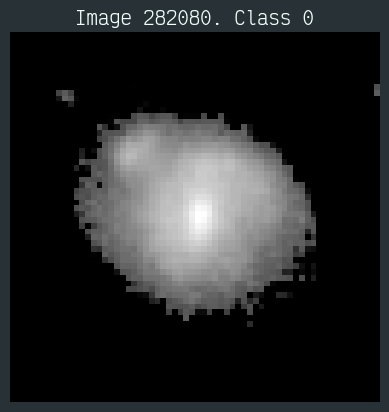

In [94]:
# Ejemplo de uso de una imágen
img_name = files2[0]
idx = metadata2_df.index[metadata2_df["image_id"] == img_name][0]
img_class = metadata2_df.at[idx, "class"]

plt.imshow(processed_images_2[img_name], cmap="gray")
plt.title(f"Image {img_name}. Class {img_class}")
plt.axis("off")
plt.show()

In [95]:
# Obtenemos un arreglo con todas las imágenes
images_ids_2 = metadata2_df["image_id"].to_list()

images_array_2 = np.empty((len(metadata2_df), 64, 64), dtype=np.float32)

for i, img_name in enumerate(images_ids_2):
    image = processed_images_2[img_name]

    # Asegurarse que las imágenes estén normalizadas
    if image.max() > 1 or image.min() < 0:
        raise ValueError(f"Image {img_name} not normalized.")

    images_array_2[i] = image

In [96]:
# Revisando la cantidad de etiquetas respecto a la cantidad de imágenes, y congruencia de tamaños
print(images_array_2.shape, metadata2_df["class"].shape)

(10570, 64, 64) (10570,)


---

##### 2. Separación de datos en entrenamiento y prueba

In [100]:
# Se genera el objeto para los datos
data2 = Data(
    X=images_array_2.astype("float32"),
    y=metadata2_df["class"].astype("int8"),
)

In [101]:
# Checar
display(data2.X_test_flat.shape)

(2114, 4096)

---

##### 3. Prueba con el mejor modelo

In [105]:
mejor_modelo = best_cnn

print(evaluate_models({"mejor_modelo": mejor_modelo}, data2).round(2))

2025-11-21 21:40:24.506286: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


         Modelo  Accuracy  Precision  Recall    F1  ROC-AUC  Parámetros  \
0  mejor_modelo      0.78       0.73    0.73  0.73     0.85      523457   

   Tiempo_inferencia_s  
0                 2.29  


2025-11-21 21:37:59.329101: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


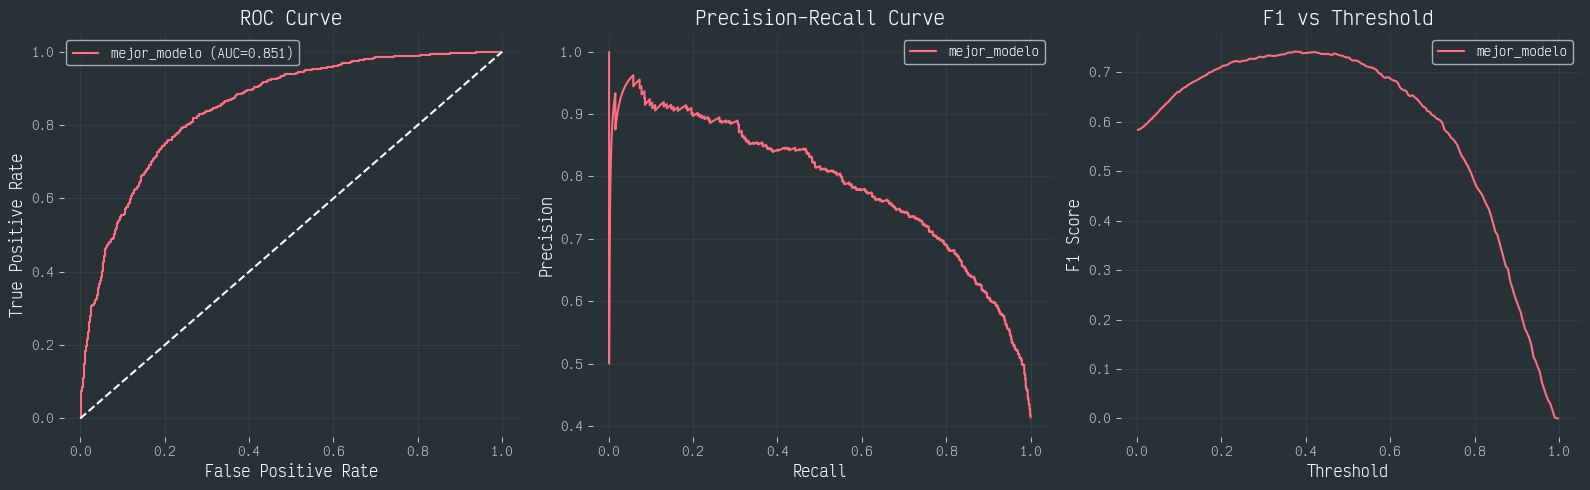

In [104]:
visualize_metrics(models={"mejor_modelo": mejor_modelo}, data=data2)

##### Conclusiones

La comparación entre modelos mostró que la CNN fue claramente la mejor opción para clasificar las imágenes. Sus resultados finales (Accuracy 0.78, F1 0.73, ROC-AUC 0.85) indican que aprendió patrones visuales relevantes y generalizó razonablemente bien en datos nuevos, aun con un costo computacional mayor y un tiempo de inferencia más largo.

El MLP y el SVC mostraron limitaciones claras: ambos pierden información espacial al trabajar con imágenes aplanadas, lo que redujo su capacidad predictiva y, en el caso del SVC, elevó el tiempo de cómputo. La Regresión Logística sirvió únicamente como línea base; fue la más rápida pero también la más débil en todas las métricas.

En conjunto, los resultados confirman que la arquitectura convolucional es la más adecuada para este tipo de datos y ofrece el mejor balance entre desempeño y estabilidad, incluso sin posibilidad de realizar más pruebas.

**Siguientes pasos:** Una mejora natural sería explorar técnicas de aumento de datos, ajustar la arquitectura con otras variantes que puedan ser más eficientes y optimizar el preprocesamiento para reducir el tiempo de inferencia sin sacrificar desempeño. Estos ajustes permitirían refinar la generalización del modelo en futuros experimentos.

---